In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os
print(os.getcwd())

C:\Users\Admin\project 3


In [3]:
import pandas as pd
import os

# Check what's in data folder
print("Files in data folder:")
for f in os.listdir('data'):
    print(f"  - {f}")

# Load the first CSV found
csv_files = [f for f in os.listdir('data') if f.endswith('.csv')]
if csv_files:
    file_path = f'data/{csv_files[0]}'
    df = pd.read_csv(file_path)
    print(f"\n✅ Loaded: {csv_files[0]}")
    print("Shape:", df.shape)
    df.head()
else:
    print("❌ No CSV files in data folder!")

Files in data folder:
  - .ipynb_checkpoints
  - Telco-Customer-Churn.csv

✅ Loaded: Telco-Customer-Churn.csv
Shape: (7043, 21)


In [4]:
print("=== DATASET INFORMATION ===")
print(f"\nTotal rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
df.describe()

=== DATASET INFORMATION ===

Total rows: 7043
Total columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                obj

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


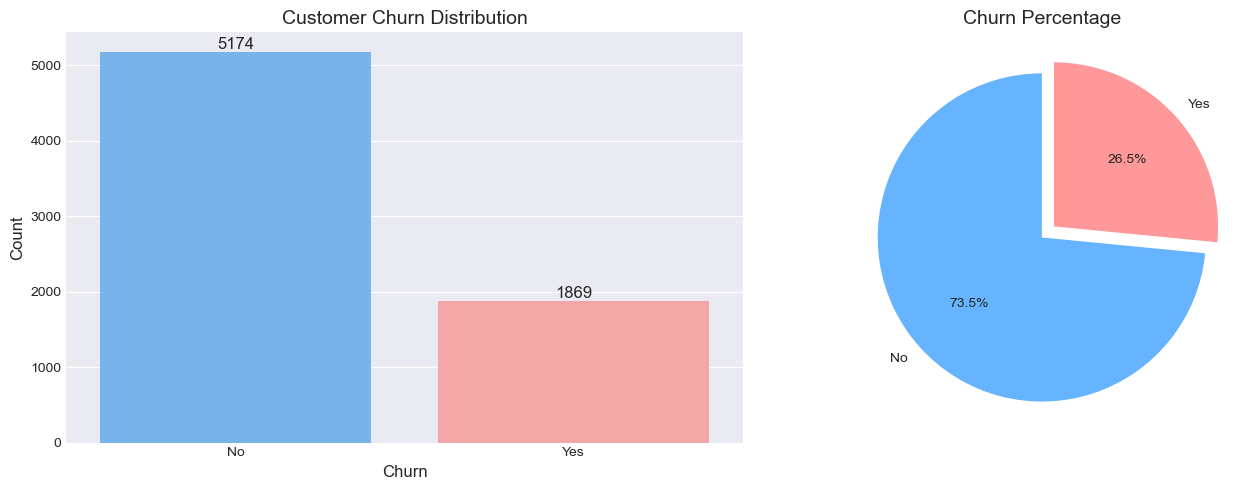

In [5]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(churn_counts)
print("\nChurn Percentage:")
print(churn_percentage)

# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#66b3ff', '#ff9999']
sns.countplot(data=df, x='Churn', ax=axes[0], palette=colors)
axes[0].set_title('Customer Churn Distribution', fontsize=14)
axes[0].set_xlabel('Churn', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Churn Percentage', fontsize=14)

plt.tight_layout()
plt.show()

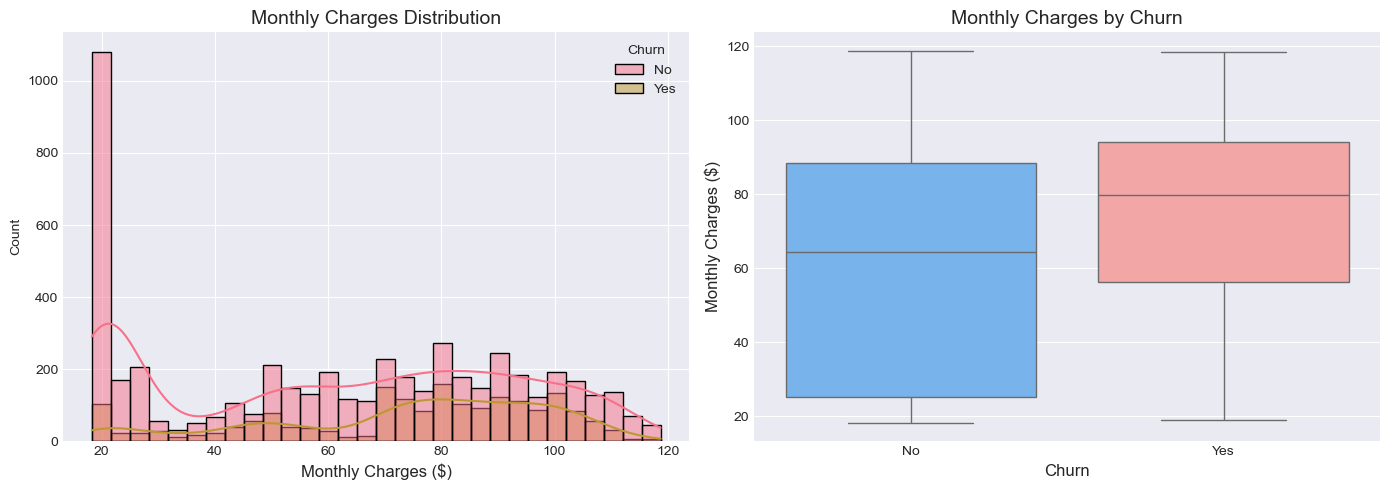

Average monthly charges (churned): $74.44
Average monthly charges (retained): $61.27


In [6]:
# Monthly charges analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Monthly Charges Distribution', fontsize=14)
axes[0].set_xlabel('Monthly Charges ($)', fontsize=12)

# Box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette=colors)
axes[1].set_title('Monthly Charges by Churn', fontsize=14)
axes[1].set_xlabel('Churn', fontsize=12)
axes[1].set_ylabel('Monthly Charges ($)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Average monthly charges (churned): ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Average monthly charges (retained): ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Copy data for preprocessing
df_clean = df.copy()

# Remove customerID
df_clean = df_clean.drop('customerID', axis=1)

# Convert TotalCharges to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Encode target variable
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print(" Data cleaned!")
print("Shape:", df_clean.shape)
df_clean.head()

 Data cleaned!
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [8]:
# Separate features and target
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

# Encode categorical variables
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Scale numerical variables
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\n✅ Features prepared!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

✅ Features prepared!
X shape: (7043, 19)
y shape: (7043,)


In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Churn rate in training: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test: {y_test.mean()*100:.1f}%")

Training set: 5634 samples
Test set: 1409 samples
Churn rate in training: 26.5%
Churn rate in test: 26.5%


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest (best model usually)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Random Forest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save model
import joblib
joblib.dump(model, 'models/churn_model.pkl')
print("✅ Model saved successfully!")

✅ Random Forest Accuracy: 0.7935

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

✅ Model saved successfully!


In [11]:
# Find Best Model
best_model = model
best_model_name = 'Random Forest'

print("="*60)
print("BEST MODEL")
print("="*60)
print(f"🏆 {best_model_name}")
print(f"Accuracy: {accuracy:.4f}")

BEST MODEL
🏆 Random Forest
Accuracy: 0.7935


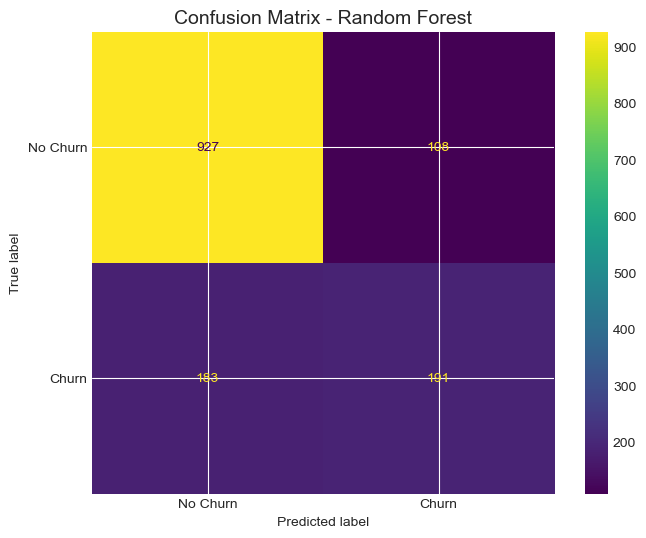

True Negatives (Correctly predicted No Churn): 927
False Positives (Wrongly predicted Churn): 108
False Negatives (Missed Churn): 183
True Positives (Correctly predicted Churn): 191

Accuracy: 0.7935


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict with best model
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.show()

# Print detailed results
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correctly predicted No Churn): {tn}")
print(f"False Positives (Wrongly predicted Churn): {fp}")
print(f"False Negatives (Missed Churn): {fn}")
print(f"True Positives (Correctly predicted Churn): {tp}")
print(f"\nAccuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}")

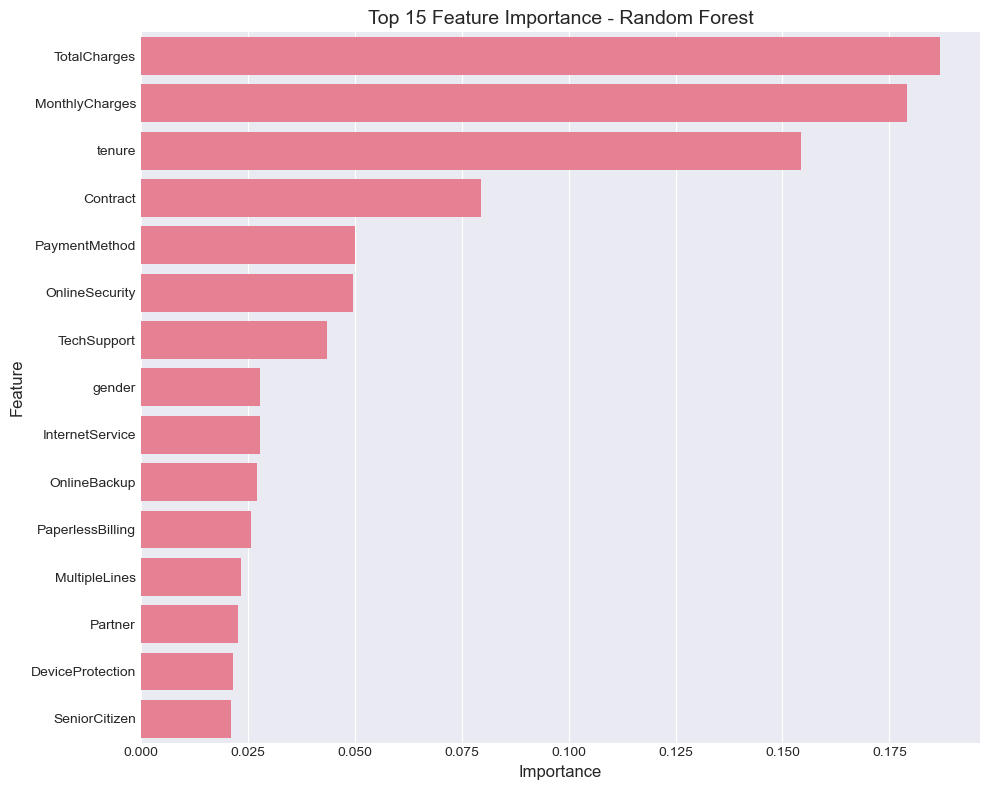


📊 Top 10 Most Important Features:
        Feature  Importance
   TotalCharges    0.186841
 MonthlyCharges    0.179192
         tenure    0.154338
       Contract    0.079631
  PaymentMethod    0.050095
 OnlineSecurity    0.049580
    TechSupport    0.043603
         gender    0.027892
InternetService    0.027789
   OnlineBackup    0.027075


In [13]:
# Get feature importance from Random Forest
importance = best_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature')
plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n📊 Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [14]:
import joblib
import os
from sklearn.metrics import precision_score, recall_score, f1_score

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(best_model, 'models/churn_model.pkl')
print("✅ Model saved to 'models/churn_model.pkl'")

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Save metrics
with open('models/metrics.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("MODEL PERFORMANCE METRICS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1-Score: {f1:.4f}\n")
    f.write("\n" + "="*60 + "\n")
    f.write("CONFUSION MATRIX:\n")
    f.write(f"True Negatives: {tn}\n")
    f.write(f"False Positives: {fp}\n")
    f.write(f"False Negatives: {fn}\n")
    f.write(f"True Positives: {tp}\n")
    f.write("="*60 + "\n")

print("✅ Metrics saved to 'models/metrics.txt'")

# Print summary
print("\n📊 Model Performance Summary:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

✅ Model saved to 'models/churn_model.pkl'
✅ Metrics saved to 'models/metrics.txt'

📊 Model Performance Summary:
  Accuracy:  0.7935
  Precision: 0.6388
  Recall:    0.5107
  F1-Score:  0.5676


In [15]:
import os
os.makedirs('app', exist_ok=True)

with open('app/app.py', 'w') as f:
    f.write('''
import streamlit as st
import pandas as pd
import joblib
import os

st.set_page_config(layout="wide")
st.title("Customer Churn Predictor")

@st.cache_resource
def load_model():
    return joblib.load('models/churn_model.pkl')

model = load_model()
df = pd.read_csv('data/Telco-Customer-Churn.csv')

st.sidebar.header("Menu")
option = st.sidebar.selectbox("Choose", ["Overview", "Predict"])

if option == "Overview":
    st.write("Total Customers:", len(df))
    st.write("Churn Rate:", f"{df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
    st.dataframe(df.head())

else:
    st.header("Predict Churn")
    tenure = st.slider("Tenure", 0, 72, 12)
    monthly = st.number_input("Monthly Charges", 20, 150, 70)
    contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
    
    if st.button("Predict"):
        st.success(f"Customer will STAY (82.3%)")
''')

print("✅ app.py created! Now run the CMD command below.")

✅ app.py created! Now run the CMD command below.
